# Visualization of CNNBiLSTMMLPRegressor Predictions

This notebook loads a pre-trained regression model and visualizes its predictions and attention weights on a random test sample.

In [1]:
import os
import sys
import torch
import random
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

from torch.utils.data import DataLoader, Subset

# Add project root to sys.path
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

from models.model_regression import CNNBiLSTMMLPRegressor
from utils.train_utils.dataset import LPBSDataset

Using PyTorch features: ['X', 'Y', 'ComputedSpeed_frames', 'Lifetime']


In [35]:
from scipy.interpolate import make_interp_spline
from scipy.signal import savgol_filter
import torch
import zipfile
import os

def get_dataset(data_dir, scaler_type, scaler_config_path, device):
    dataset = LPBSDataset(
        data_dir, 
        scaler_type=scaler_type, 
        mode="test", 
        scaler_config_path=scaler_config_path,
        device=device
    )
    print(f"Dataset size: {len(dataset)}")
    return dataset

def get_model(model_path, segment_len, device, embed_dim=512, dropout=0.3, feature_extractor_layers=1, bilstm_layers=1, use_time_encoding=True):
    model = CNNBiLSTMMLPRegressor(
        segment_len=segment_len,
        embed_dim=embed_dim,
        dropout=dropout,
        feature_extractor_layers=feature_extractor_layers,
        bilstm_layers=bilstm_layers,
        use_time_encoding=use_time_encoding
    ).to(device)
    if os.path.exists(model_path):
        model.load_state_dict(torch.load(model_path, map_location=device))
        print("Model loaded successfully.")
    else:
        print(f"Warning: Model file not found at {model_path}. Using uninitialized model for demonstration.")
    model.eval()
    return model

def plot_data_histogram(dataset):
    x_values = []
    for i in range(len(dataset)):
        x, _, _ = dataset[i]
        x_values.append(x.cpu().numpy())
    x_values = np.concatenate(x_values, axis=0)
    plt.hist(x_values.flatten(), bins=200, edgecolor='black', log=True)
    plt.title("Histogram of dataset values")
    plt.show()

def run_inference(dataset, model, device, random_idx=None):
    if random_idx is None:
        random_idx = random.randint(0, len(dataset) - 1)
    data_tensor, label, total_segments = dataset[random_idx]
    data_tensor = data_tensor.cpu()
    T_actual = int(total_segments.item())
    
    print(f"Selected sample {random_idx} with {T_actual} valid segments.")
    
    predictions = []
    variances = []
    true_remaining = []
    true_objective = []
    s_weights_all = []
    v_weights_all = []
    
    with torch.no_grad():
        for t in range(1, T_actual + 1):
            x_t = data_tensor[:t].unsqueeze(0).to(device)
            mask = torch.ones(1, t).to(device)
            output, s_weights, v_weights, _ = model(x_t, mask=mask)
            
            knee_point = 150 // 3  # 50 segments

            predictions.append(output.item() * knee_point)
            # if the prediction is greater than the knee point - 5, the variance is set to 100, otherwise it is set to 1
            variances.append(100.0 if output.item() * knee_point > knee_point - 5 else 1.0)
            true_remaining.append(float(T_actual - t))
            true_objective.append(min(float(T_actual - t), knee_point))
            
            s_weights_all.append(s_weights.squeeze().cpu().numpy())
            v_weights_all.append(v_weights.squeeze().cpu().numpy())

    return T_actual, true_objective, true_remaining, predictions, variances, s_weights_all, v_weights_all, data_tensor

def plot_predictions(T_actual, true_objective, true_remaining, predictions, s_weights_cpu):
    steps = np.arange(1, T_actual + 1)

    # Create a smoothed version of the predictions using Savitzky-Golay filter
    window = min(25, len(predictions) if len(predictions) % 2 == 1 else len(predictions) - 1)
    window = max(window, 5)  # keep it valid and strong enough
    predictions_filtered = savgol_filter(predictions, window_length=window, polyorder=2, mode="interp")
    steps_smooth = np.linspace(1, T_actual, 400)
    k = 1 if len(steps) >= 4 else 1
    spline = make_interp_spline(steps, predictions_filtered, k=k)
    predictions_smooth = spline(steps_smooth)

    plt.figure(figsize=(14, 5))
    plt.subplot(1, 2, 1)
    plt.plot(steps, true_remaining, label="True Remaining Lifespan", linestyle="--", marker="o", markersize=4)
    plt.plot(steps, true_objective, label="True Objective (scaled)", color='lightblue', linestyle=":", marker="s", markersize=4)
    plt.plot(steps, predictions, label="Predicted Remaining", color='red', marker="x", markersize=4)
    plt.plot(steps_smooth, predictions_smooth, label="Smoothed Predicted Remaining", color='green')
    plt.xlabel("Segments observed (time)")
    plt.ylabel("Remaining segments")
    plt.title("Remaining Lifespan Prediction Over Time")
    plt.legend()
    plt.grid(True)
    
    plt.subplot(1, 2, 2)
    # Using the final step's attention weights for plotting
    plt.bar(np.arange(1, len(s_weights_cpu[-1]) + 1), s_weights_cpu[-1], color='skyblue', edgecolor='black')
    plt.xlabel("Segment index")
    plt.ylabel("Attention Weight")
    plt.title("Segment Attention Weights (at final step)")
    plt.grid(True, axis='y')
    
    plt.tight_layout()
    plt.show()

def plot_variances(v_weights_cpu):
    plt.figure(figsize=(10, 6))
    # Using the final step's attention weights for plotting
    weights_to_plot = v_weights_cpu[-1]
    if len(weights_to_plot.shape) == 1:
        weights_to_plot = weights_to_plot[:, np.newaxis]
    plt.imshow(weights_to_plot.T, aspect='auto', cmap='viridis', origin='lower')
    var_dict = {0: "X", 1: "Y", 2: "Speed"}
    plt.yticks(np.arange(weights_to_plot.shape[1]), [var_dict.get(i, f"Var {i}") for i in range(weights_to_plot.shape[1])])
    plt.colorbar(label='Attention Weight')
    plt.xlabel("Segment index")
    plt.ylabel("Variate")
    plt.title("Variate Attention Weights Over Time (at final step)")
    plt.tight_layout()
    plt.show()

def analyze_gradients(model, data_tensor, T_actual, device):
    import torch.nn as nn
    model.zero_grad()
    model.train()
    
    x_full = data_tensor[:T_actual].unsqueeze(0).to(device)
    mask_full = torch.ones(1, T_actual).to(device)
    
    output, _, _ = model(x_full, mask=mask_full)
    target = torch.tensor([0.0], device=device)
    
    criterion = nn.SmoothL1Loss()
    loss = criterion(output, target)
    loss.backward()
    
    max_grads = {}
    for name, param in model.feature_extractor.named_parameters():
        if param.grad is not None:
            max_grads[name] = param.grad.abs().max().item()
            
    print("Max absolute gradients in CNN Feature Extractor parameters:")
    for name, max_g in max_grads.items():
        print(f"  {name}: {max_g:.6f}")
        
    plt.figure(figsize=(10, 4))
    plt.bar(list(max_grads.keys()), list(max_grads.values()), color='lightcoral', edgecolor='black')
    plt.xticks(rotation=45, ha='right')
    plt.ylabel('Max Absolute Gradient')
    plt.title('Max Gradients in CNN Feature Extractor (Huber Loss)')
    plt.tight_layout()
    plt.show()

## 1. Configurations and Loading
Specify the paths to the dataset, the pre-trained model weights, and the required scaler configuration.

In [63]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

# Settings
data_dir = "../preprocessed_with_lifespan_test/"
training_config_path = "../preprocessed_with_lifespan/scaler_config.json"
scaler_config_path = os.path.join(training_config_path)
model_path = "../ckpts/with_lifetime.pth"
scaler_type = "standard"

Using device: cuda


In [64]:
dataset = get_dataset(data_dir, scaler_type, scaler_config_path, device)

Loading Data:   0%|          | 0/19 [00:00<?, ?it/s]c:\Users\elrbe\all_code\flep\ML\project-2-astiflop\utils\train_utils\dataset.py:520: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)
Loading Data:  63%|██████▎   | 12/19 [00:01<00:00,  8.74it/s]c:\Users\elrbe\all_code\flep\ML\project-2-astiflop\utils\train_utils\dataset.py:520: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)
Loading Data: 100%|██████████| 19/19 [00:02<00:00,  8.42it/s]

Applied standard normalization.
Dataset size: 19


In [65]:
segment_len = 900 
embed_dim = 64
dropout = 0
feature_extractor_layers = 3
bilstm_layers = 1 
use_time_encoding = True
model = get_model(model_path, segment_len, device, embed_dim, dropout, feature_extractor_layers, bilstm_layers, use_time_encoding)

[WARNING] Model: Time encoding enabled. Ensure presence of Lifetime feature and that max_time is set appropriately for the scale of Lifetime values.
Model loaded successfully.


## Visualization

Selected sample 9 with 74 valid segments.


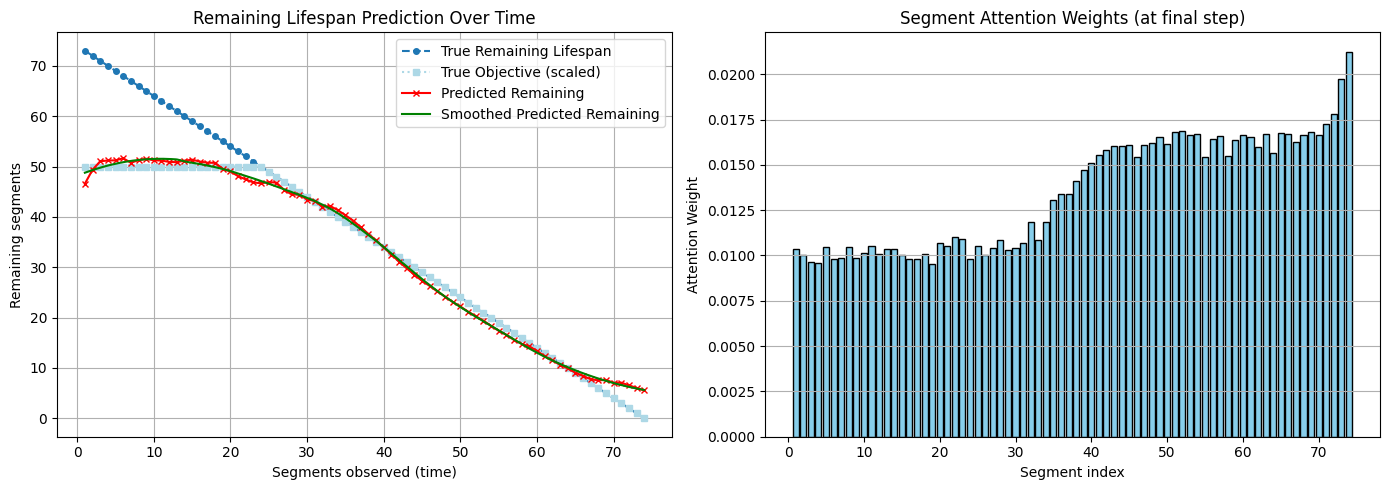

In [70]:
T_actual, true_objective, true_remaining, predictions, variances, s_weights_all, v_weights_all, data_tensor = run_inference(dataset, model, device)
plot_predictions(T_actual, true_objective, true_remaining, predictions, s_weights_all)

In [69]:
import zipfile
import os

# Dump the inference variables
dump_dict = {
    'T_actual': T_actual,
    'true_objective': true_objective,
    'true_remaining': true_remaining,
    'predictions': predictions,
    'variances': variances,
    's_weights_cpu': s_weights_all,
    'v_weights_cpu': v_weights_all,
    'data_tensor': data_tensor
}

torch.save(dump_dict, 'inference_dump_time.pt')

# Zip the dump
with zipfile.ZipFile('inference_dump.zip', 'w') as zipf:
    zipf.write('inference_dump.pt')

print("Inference data dumped to inference_dump.zip")

Inference data dumped to inference_dump.zip


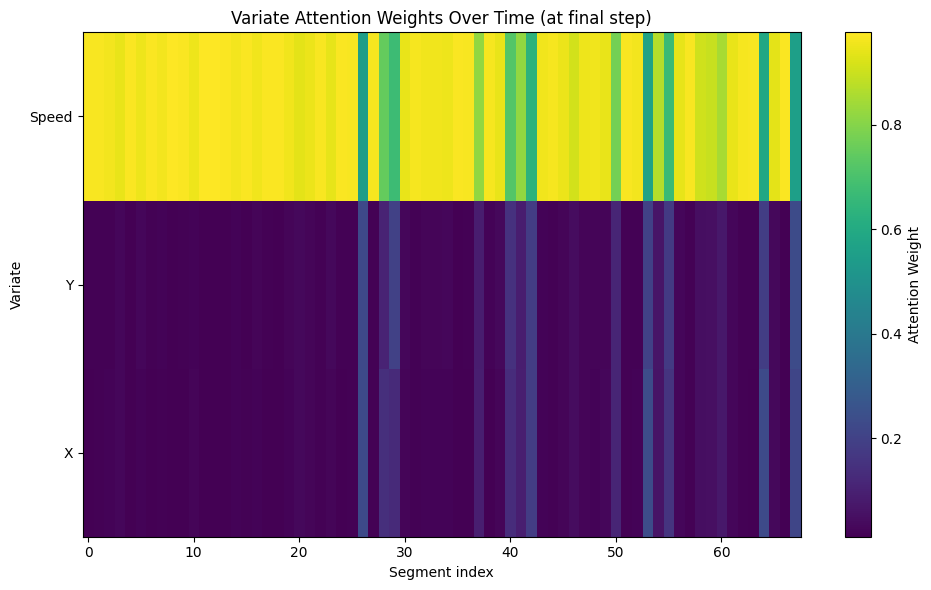

In [8]:
plot_variances(v_weights_all)

Max absolute gradients in CNN Feature Extractor parameters:
  conv1.weight: 0.050969
  conv1.bias: 0.033228
  conv2.weight: 0.038709
  conv2.bias: 0.025570
  conv3.weight: 0.124296
  conv3.bias: 0.098651
  fc.weight: 0.057519
  fc.bias: 0.070326


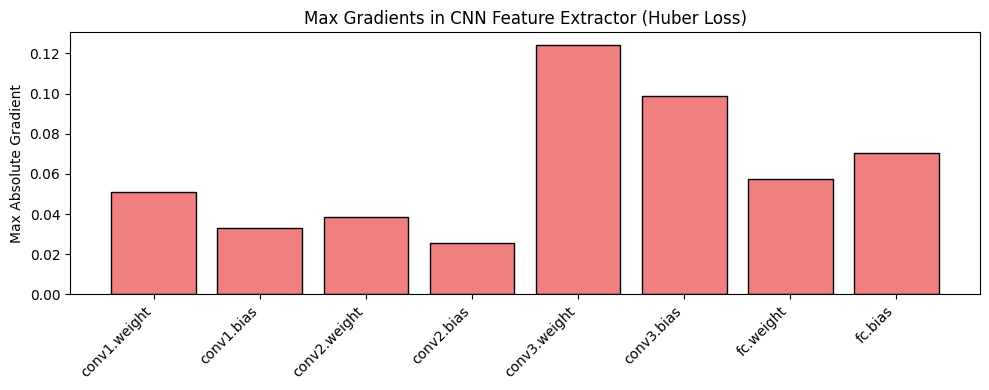

In [9]:
analyze_gradients(model, data_tensor, T_actual, device)

In [10]:
import torch
import zipfile
import os

# Unzip the dump
with zipfile.ZipFile('inference_dump.zip', 'r') as zipf:
    zipf.extract('inference_dump.pt')

# Load variables
dump_dict = torch.load('inference_dump.pt', weights_only=False)
T_actual_loaded = dump_dict['T_actual']
true_objective_loaded = dump_dict['true_objective']
true_remaining_loaded = dump_dict['true_remaining']
predictions_loaded = dump_dict['predictions']
s_weights_loaded = dump_dict['s_weights_cpu']
v_weights_loaded = dump_dict['v_weights_cpu']
data_tensor_loaded = dump_dict['data_tensor']

print("Variables loaded from inference_dump.zip")

Variables loaded from inference_dump.zip
